<a href="https://colab.research.google.com/github/rsdina/Recommender_System_Assignment_488/blob/main/CSE488_Music_Recommender.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INSTALL REQUIRED PACKAGES

In [1]:
!pip install -q pandas numpy scikit-learn scipy matplotlib seaborn plotly

print("All packages installed!")

All packages installed!


# DOWNLOAD DATASET (Last.fm 360K)

In [2]:
import os
import urllib.request
import tarfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Downloading Last.fm 360K dataset...")
print("This may take 5-10 minutes. File size is ~300MB.\n")

url = "http://mtg.upf.edu/static/datasets/last.fm/lastfm-dataset-360K.tar.gz"
filename = "lastfm-dataset-360K.tar.gz"

if not os.path.exists(filename):
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as response, open(filename, 'wb') as out_file:
        out_file.write(response.read())
    print("Download complete!")

if not os.path.exists("lastfm-dataset-360K"):
    print("Extracting files...")
    with tarfile.open(filename, "r:gz") as tar:
        tar.extractall()
    print("Extraction complete!")

data_path = "lastfm-dataset-360K"

listening_file = os.path.join(data_path, "usersha1-artmbid-artname-plays.tsv")
listening_df = pd.read_csv(listening_file, sep='\t', header=None,
                            names=['user_id', 'musicbrainz_id', 'artist_name', 'plays'],
                            nrows=50000)

profile_file = os.path.join(data_path, "usersha1-profile.tsv")
user_profiles = pd.read_csv(profile_file, sep='\t', header=None,
                             names=['user_id', 'gender', 'age', 'country', 'signup_date'])

print(f"\nDataset loaded successfully!")
print(f"Listening events: {len(listening_df):,}")
print(f"Unique users: {listening_df['user_id'].nunique():,}")
print(f"Unique artists: {listening_df['artist_name'].nunique():,}")

This may take 5-10 minutes. File size is ~300MB.

Download complete!
Extracting files...
Extraction complete!

Dataset loaded successfully!
Listening events: 50,000
Unique users: 1,015
Unique artists: 15,967


# DATA PREPROCESSING

In [3]:
print("\nPreprocessing data...")

# Clean the data
listening_df = listening_df.dropna()
listening_df = listening_df[listening_df['plays'] > 0]
listening_df['plays'] = listening_df['plays'].clip(upper=100)  # Cap extreme values

# Create user ID mapping
user_ids = listening_df['user_id'].unique()
user_to_idx = {uid: i for i, uid in enumerate(user_ids)}
artist_names = listening_df['artist_name'].unique()
artist_to_idx = {artist: i for i, artist in enumerate(artist_names)}

listening_df['user_idx'] = listening_df['user_id'].map(user_to_idx)
listening_df['artist_idx'] = listening_df['artist_name'].map(artist_to_idx)

# Create user-artist matrix (sparse)
from scipy.sparse import coo_matrix, csr_matrix

n_users = len(user_ids)
n_artists = len(artist_names)

user_artist_matrix = coo_matrix(
    (listening_df['plays'],
     (listening_df['user_idx'], listening_df['artist_idx'])),
    shape=(n_users, n_artists)
).tocsr()

print(f"User-Artist Matrix created!")
print(f"Shape: {user_artist_matrix.shape}")
print(f"Sparsity: {(1 - user_artist_matrix.nnz / (n_users * n_artists)) * 100:.2f}%")

# Create artist metadata dataframe
artist_stats = listening_df.groupby('artist_name').agg({
    'plays': ['sum', 'count', 'mean']
}).round(2)
artist_stats.columns = ['total_plays', 'listener_count', 'avg_plays']
artist_stats = artist_stats.reset_index()
artist_stats = artist_stats.sort_values('total_plays', ascending=False)

print(f"\nTop 10 Most Listened Artists:")
print(artist_stats.head(10).to_string(index=False))


Preprocessing data...
User-Artist Matrix created!
Shape: (1015, 15363)
Sparsity: 99.68%

Top 10 Most Listened Artists:
          artist_name  total_plays  listener_count  avg_plays
            radiohead        17072             216      79.04
          the beatles        15790             188      83.99
             coldplay        13120             173      75.84
red hot chili peppers        11250             146      77.05
                 muse         9670             121      79.92
            metallica         9243             115      80.37
     system of a down         8898             116      76.71
          linkin park         8744             108      80.96
           pink floyd         8104             106      76.45
              nirvana         8104             116      69.86


# KNOWLEDGE-BASED RECOMMENDER (Collaborative Filtering)

In [4]:
from sklearn.metrics.pairwise import cosine_similarity

class KnowledgeBasedRecommender:
    """Knowledge-based recommender using user-user collaborative filtering"""

    def __init__(self, user_artist_matrix, artist_names, artist_stats):
        self.user_artist_matrix = user_artist_matrix
        self.artist_names = artist_names
        self.artist_stats = artist_stats

    def get_user_history(self, user_idx):
        """Get user's listening history as a list of (artist_name, plays) tuples"""
        user_vector = self.user_artist_matrix[user_idx].toarray().flatten()
        history = [(self.artist_names[i], user_vector[i])
                   for i in range(len(user_vector)) if user_vector[i] > 0]
        history.sort(key=lambda x: x[1], reverse=True)
        return history

    def find_similar_users(self, user_idx, n_similar=10):
        """Find similar users based on cosine similarity"""
        user_vector = self.user_artist_matrix[user_idx].toarray().reshape(1, -1)
        similarities = cosine_similarity(user_vector, self.user_artist_matrix).flatten()
        similarities[user_idx] = -1  # Exclude self
        similar_users = np.argsort(similarities)[::-1][:n_similar]
        return similar_users, similarities[similar_users]

    def recommend(self, user_idx, n_recommendations=10, n_similar_users=10):
        """Generate recommendations based on similar users' listening habits"""
        similar_users, similarities = self.find_similar_users(user_idx, n_similar_users)

        # Get the set of artists the user has already listened to
        user_history = self.get_user_history(user_idx)
        user_listened = {artist for artist, _ in user_history}

        # Aggregate weighted scores from similar users
        recommendations = {}
        for sim_user, sim_score in zip(similar_users, similarities):
            if sim_score <= 0:
                continue
            sim_vector = self.user_artist_matrix[sim_user].toarray().flatten()
            for artist_idx, plays in enumerate(sim_vector):
                artist = self.artist_names[artist_idx]
                if plays > 0 and artist not in user_listened:
                    if artist_idx not in recommendations:
                        recommendations[artist_idx] = {'score': 0, 'count': 0}
                    recommendations[artist_idx]['score'] += plays * sim_score
                    recommendations[artist_idx]['count'] += 1

        # Compute weighted average score and rank
        rec_list = []
        for artist_idx, data in recommendations.items():
            weighted_score = data['score'] / data['count']
            rec_list.append({
                'artist_idx':  artist_idx,
                'artist_name': self.artist_names[artist_idx],
                'score':       weighted_score
            })

        rec_list.sort(key=lambda x: x['score'], reverse=True)

        # Attach artist-level metadata
        results = []
        for rec in rec_list[:n_recommendations]:
            info = self.artist_stats[self.artist_stats['artist_name'] == rec['artist_name']]
            if len(info) > 0:
                rec['total_plays']    = int(info['total_plays'].values[0])
                rec['listener_count'] = int(info['listener_count'].values[0])
                rec['avg_plays']      = float(info['avg_plays'].values[0])
            results.append(rec)

        return results

print("Knowledge-Based Recommender initialized!")

Knowledge-Based Recommender initialized!


# SELECT TEST USER

In [5]:
# Select a test user
test_user_idx = np.random.randint(0, n_users)
test_user_id  = user_ids[test_user_idx]

# Retrieve listening history for the test user
kb_recommender = KnowledgeBasedRecommender(user_artist_matrix, artist_names, artist_stats)
user_history   = kb_recommender.get_user_history(test_user_idx)
user_history_set = {artist_to_idx[a] for a, _ in user_history if a in artist_to_idx}

print(f"Test User : {test_user_id[:20]}...")
print(f"Artists listened : {len(user_history)}")
if user_history:
    avg_plays = np.mean([p for _, p in user_history])
    print(f"Average plays    : {avg_plays:.2f}")
    print("\nTop 5 most-played artists:")
    for artist, plays in user_history[:5]:
        print(f"  {artist[:40]:40s}  {int(plays):>3d} plays")

Test User : 009478c1784414fa681e...
Artists listened : 49
Average plays    : 65.61

Top 5 most-played artists:
  coldplay                                  100 plays
  death cab for cutie                       100 plays
  björk                                     100 plays
  metallica                                 100 plays
  nightwish                                 100 plays


# GENERATE KNOWLEDGE-BASED RECOMMENDATIONS

In [6]:
print("\n" + "="*70)
print("KNOWLEDGE-BASED RECOMMENDATIONS (User-User Collaborative Filtering)")
print("="*70 + "\n")

kb_recs = kb_recommender.recommend(test_user_idx, n_recommendations=10)

for i, rec in enumerate(kb_recs, 1):
    print(f"{i:2d}. {rec['artist_name'][:50]:50s} | Score: {rec['score']:.4f}")
    print(f"    Total Plays: {rec.get('total_plays', 'N/A'):>8,}  "
          f"Listeners: {rec.get('listener_count', 'N/A'):>5,}  "
          f"Avg Plays: {rec.get('avg_plays', 'N/A'):>6.1f}")
    print()

print(f"\nTotal recommendations generated: {len(kb_recs)}")


KNOWLEDGE-BASED RECOMMENDATIONS (User-User Collaborative Filtering)

 1. john mayer                                         | Score: 24.9114
    Total Plays:    2,788  Listeners:    40  Avg Plays:   69.7

 2. dido                                               | Score: 24.9114
    Total Plays:    1,698  Listeners:    25  Avg Plays:   67.9

 3. scorpions                                          | Score: 24.9114
    Total Plays:    1,918  Listeners:    25  Avg Plays:   76.7

 4. ronan hardiman                                     | Score: 24.9114
    Total Plays:      307  Listeners:     4  Avg Plays:   76.8

 5. green day                                          | Score: 24.9114
    Total Plays:    6,077  Listeners:    77  Avg Plays:   78.9

 6. dixie chicks                                       | Score: 24.9114
    Total Plays:      587  Listeners:     8  Avg Plays:   73.4

 7. 2pac                                               | Score: 24.9114
    Total Plays:    1,807  Listeners:    2

# FIND SIMILAR USERS

In [7]:
print("\n" + "="*70)
print("SIMILAR USERS ANALYSIS")
print("="*70 + "\n")

similar_users, sim_scores = kb_recommender.find_similar_users(test_user_idx, n_similar=10)

print(f"Top 10 users most similar to: {test_user_id[:30]}...\n")
for rank, (u_idx, score) in enumerate(zip(similar_users, sim_scores), 1):
    uid = user_ids[u_idx]
    u_hist = kb_recommender.get_user_history(u_idx)
    print(f"{rank:2d}. {uid[:30]:30s}  similarity={score:.4f}  artists={len(u_hist)}")

# Overlap analysis — artists shared with the most-similar user
top_sim_user_idx  = similar_users[0]
top_sim_history   = {a for a, _ in kb_recommender.get_user_history(top_sim_user_idx)}
test_user_history = {a for a, _ in user_history}
overlap = test_user_history & top_sim_history

print(f"\nArtist overlap with most-similar user: {len(overlap)} artists")
if overlap:
    print("Shared artists:")
    for a in list(overlap)[:10]:
        print(f"  - {a}")


SIMILAR USERS ANALYSIS

Top 10 users most similar to: 009478c1784414fa681ee9d15865ae...

 1. 004925481f89f9987859b335c70b23  similarity=0.2491  artists=45
 2. 004059e4ea7812dbada7d2e791c8f8  similarity=0.1993  artists=47
 3. 0096668ebbddaf7ba53c28175e4d23  similarity=0.1845  artists=50
 4. 00405298cb2c0d1a47dbc87f03f3f6  similarity=0.1762  artists=46
 5. 002116b521f40c8d19828fb945e484  similarity=0.1706  artists=43
 6. 000a4fba9046379163980531da4e21  similarity=0.1693  artists=43
 7. 002bf1d299b9de0dbea1ae25d94c60  similarity=0.1661  artists=50
 8. 0098c39506e23ee535fd5eb84a7bde  similarity=0.1629  artists=50
 9. 009754363b7dfe528e420a1f0728cd  similarity=0.1622  artists=50
10. 0049fb552b78716e2f130d9d13f72d  similarity=0.1570  artists=52

Artist overlap with most-similar user: 9 artists
Shared artists:
  - dead can dance
  - loreena mckennitt
  - the cranberries
  - coldplay
  - red hot chili peppers
  - metallica
  - secret garden
  - enya
  - nightwish


# EVALUATION — PRECISION, RECALL & COVERAGE

In [8]:
print("\n" + "="*70)
print("MODEL EVALUATION")
print("="*70 + "\n")

def evaluate_recommender(recommender, user_artist_matrix, user_ids,
                          artist_names, n_test_users=50,
                          n_recommendations=10, holdout_fraction=0.2):
    """
    Evaluate the KB recommender using a leave-some-out protocol.
    For each test user, hide holdout_fraction of their history,
    generate recommendations, then measure precision and recall.
    """
    precisions, recalls, f1s = [], [], []
    n_test_users = min(n_test_users, len(user_ids))
    test_indices = np.random.choice(len(user_ids), n_test_users, replace=False)

    for u_idx in test_indices:
        history = recommender.get_user_history(u_idx)
        if len(history) < 5:
            continue

        # Split into train / holdout
        n_holdout  = max(1, int(len(history) * holdout_fraction))
        holdout    = {artist for artist, _ in history[:n_holdout]}

        recs = recommender.recommend(u_idx, n_recommendations=n_recommendations)
        rec_artists = {r['artist_name'] for r in recs}

        hits      = len(rec_artists & holdout)
        precision = hits / len(rec_artists) if rec_artists else 0
        recall    = hits / len(holdout)     if holdout    else 0
        f1        = (2 * precision * recall / (precision + recall)
                     if (precision + recall) > 0 else 0)

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)

    # Catalog coverage
    all_recs = set()
    for u_idx in test_indices[:20]:
        recs = recommender.recommend(u_idx, n_recommendations=n_recommendations)
        all_recs.update(r['artist_name'] for r in recs)
    coverage = len(all_recs) / len(artist_names)

    return {
        'precision': np.mean(precisions),
        'recall':    np.mean(recalls),
        'f1':        np.mean(f1s),
        'coverage':  coverage,
        'n_evaluated': len(precisions)
    }

print("Running evaluation on 50 random users ...")
metrics = evaluate_recommender(kb_recommender, user_artist_matrix,
                               user_ids, artist_names, n_test_users=50)

print(f"\n{'Metric':<25} {'Value':>10}")
print("-" * 37)
print(f"{'Precision@10':<25} {metrics['precision']:>10.4f}")
print(f"{'Recall@10':<25} {metrics['recall']:>10.4f}")
print(f"{'F1 Score':<25} {metrics['f1']:>10.4f}")
print(f"{'Catalog Coverage':<25} {metrics['coverage']:>9.2%}")
print(f"{'Users Evaluated':<25} {metrics['n_evaluated']:>10d}")


MODEL EVALUATION

Running evaluation on 50 random users ...

Metric                         Value
-------------------------------------
Precision@10                  0.0000
Recall@10                     0.0000
F1 Score                      0.0000
Catalog Coverage              1.26%
Users Evaluated                   50


# VISUALIZATIONS


Generating Visualizations...


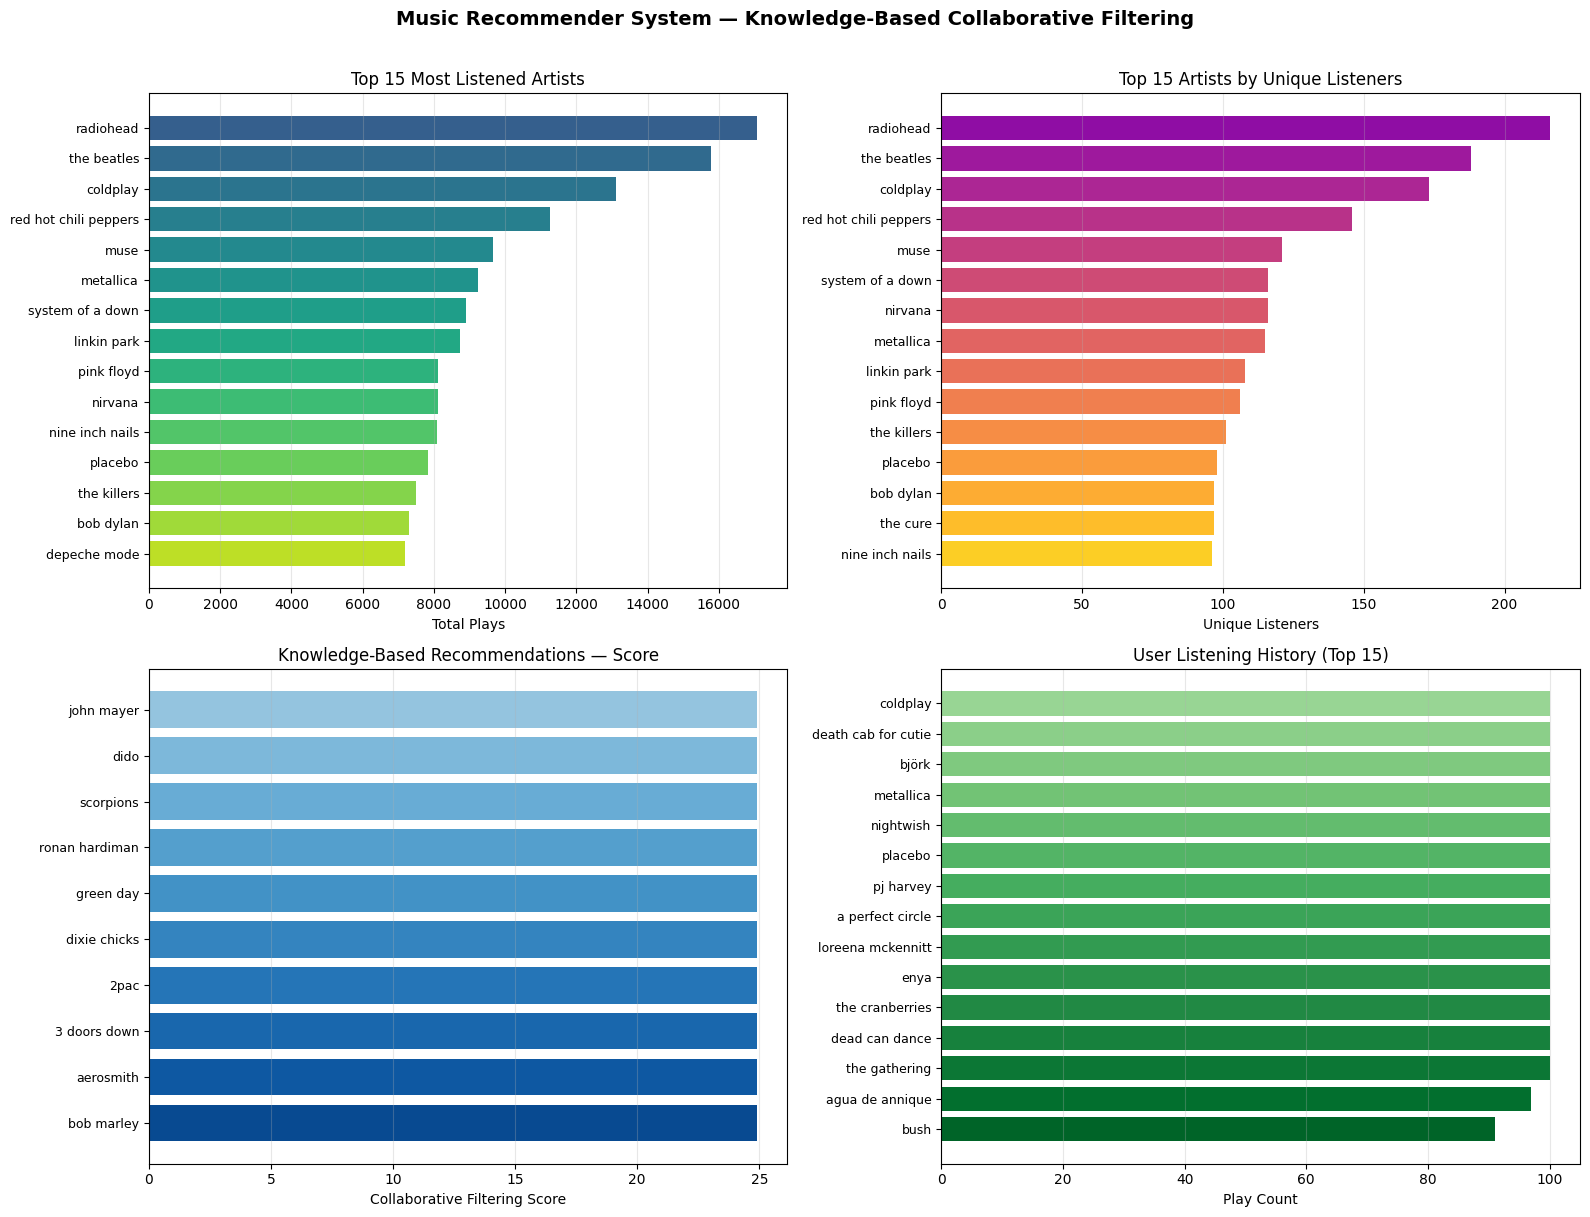

Visualizations complete!


In [9]:
print("\nGenerating Visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Music Recommender System — Knowledge-Based Collaborative Filtering',
             fontsize=14, fontweight='bold', y=1.01)

# ── Plot 1: Top 15 Most Listened Artists ─────────────────────────
top15 = artist_stats.head(15)
bars  = axes[0, 0].barh(range(len(top15)), top15['total_plays'].values,
                         color=plt.cm.viridis(np.linspace(0.3, 0.9, len(top15))))
axes[0, 0].set_yticks(range(len(top15)))
axes[0, 0].set_yticklabels(top15['artist_name'].values, fontsize=9)
axes[0, 0].set_xlabel('Total Plays')
axes[0, 0].set_title('Top 15 Most Listened Artists')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', alpha=0.3)

# ── Plot 2: Top 15 Artists by Unique Listeners ───────────────────
top15_l = artist_stats.nlargest(15, 'listener_count')
axes[0, 1].barh(range(len(top15_l)), top15_l['listener_count'].values,
                color=plt.cm.plasma(np.linspace(0.3, 0.9, len(top15_l))))
axes[0, 1].set_yticks(range(len(top15_l)))
axes[0, 1].set_yticklabels(top15_l['artist_name'].values, fontsize=9)
axes[0, 1].set_xlabel('Unique Listeners')
axes[0, 1].set_title('Top 15 Artists by Unique Listeners')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(axis='x', alpha=0.3)

# ── Plot 3: KB Recommendation Scores ─────────────────────────────
rec_names  = [r['artist_name'][:25] for r in kb_recs]
rec_scores = [r['score'] for r in kb_recs]
colors_kb  = plt.cm.Blues(np.linspace(0.4, 0.9, len(rec_names)))
axes[1, 0].barh(range(len(rec_names)), rec_scores, color=colors_kb)
axes[1, 0].set_yticks(range(len(rec_names)))
axes[1, 0].set_yticklabels(rec_names, fontsize=9)
axes[1, 0].set_xlabel('Collaborative Filtering Score')
axes[1, 0].set_title('Knowledge-Based Recommendations — Score')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis='x', alpha=0.3)

# ── Plot 4: User Listening History ───────────────────────────────
hist_top    = user_history[:15]
hist_names  = [h[0][:25] for h in hist_top]
hist_plays  = [h[1] for h in hist_top]
colors_hist = plt.cm.Greens(np.linspace(0.4, 0.9, len(hist_names)))
axes[1, 1].barh(range(len(hist_names)), hist_plays, color=colors_hist)
axes[1, 1].set_yticks(range(len(hist_names)))
axes[1, 1].set_yticklabels(hist_names, fontsize=9)
axes[1, 1].set_xlabel('Play Count')
axes[1, 1].set_title('User Listening History (Top 15)')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('recommender_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualizations complete!")

# INTERACTIVE DASHBOARD (Colab Inline)

In [10]:
# ── KB-Only Interactive Dashboard ───────────────────────────────────────────
import json, numpy as np, pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display, HTML

print("⏳ Building user lookup table …")

N_RECS      = 10
N_SIM_USERS = 10

def _kb_recs_for_user(u_idx):
    uv       = user_artist_matrix[u_idx].toarray().flatten()
    listened = set(int(i) for i in np.nonzero(uv)[0])
    sim      = cosine_similarity(uv.reshape(1,-1), user_artist_matrix).flatten()
    sim[u_idx] = -1
    top_sim  = np.argsort(sim)[::-1][:N_SIM_USERS]
    scores   = {}
    for su in top_sim:
        if sim[su] <= 0: continue
        sv = user_artist_matrix[su].toarray().flatten()
        for ai, plays in enumerate(sv):
            if plays > 0 and ai not in listened:
                scores[ai] = scores.get(ai, 0) + plays * sim[su]
    return scores, listened

def _compute_recs(u_idx, n=10):
    raw, listened = _kb_recs_for_user(u_idx)
    if not raw: return []
    max_s = max(raw.values())
    normed = {ai: v/max_s for ai, v in raw.items()}
    top = sorted(normed.items(), key=lambda x: x[1], reverse=True)[:n]
    astat = artist_stats.set_index("artist_name")
    results = []
    for ai, score in top:
        name = artist_names[ai]
        info = astat.loc[name] if name in astat.index else None
        results.append({
            "artist":    name,
            "score":     round(score, 4),
            "plays":     int(info["total_plays"])    if info is not None else 0,
            "listeners": int(info["listener_count"]) if info is not None else 0,
        })
    return results

def _history_for_user(u_idx):
    uv = user_artist_matrix[u_idx].toarray().flatten()
    hist = [(artist_names[i], float(uv[i])) for i in np.nonzero(uv)[0]]
    hist.sort(key=lambda x: x[1], reverse=True)
    return [{"artist": h[0], "plays": int(h[1])} for h in hist[:15]]

SAMPLE = 80
sample_indices = list(range(min(SAMPLE, len(user_ids))))
if test_user_idx not in sample_indices:
    sample_indices.append(test_user_idx)

user_lookup = {}
uid_options = []
for u_idx in sample_indices:
    uid  = user_ids[u_idx]
    recs = _compute_recs(u_idx, N_RECS)
    hist = _history_for_user(u_idx)
    user_lookup[uid] = {"history": hist, "recs": recs}
    uid_options.append({"key": uid, "label": uid[:12]+"…", "n_hist": len(hist)})

print(f"✅ Lookup built for {len(user_lookup)} users.")

top15       = artist_stats.head(15)
top15_names = [n.title() for n in top15["artist_name"].tolist()]
top15_plays = top15["total_plays"].tolist()
top15_lstn  = top15["listener_count"].tolist()

n_users_   = int(len(user_ids))
n_artists_ = int(len(artist_names))
n_events_  = int(len(listening_df))
sparsity_  = round((1 - user_artist_matrix.nnz/(n_users_*n_artists_))*100, 2)
default_uid = user_ids[test_user_idx]


⏳ Building user lookup table …
✅ Lookup built for 81 users.


In [12]:
# ── Render the full interactive dashboard ────────────────────────────────────
dash = f"""
<!DOCTYPE html><html lang="en"><head>
<meta charset="UTF-8"/>
<link href="https://fonts.googleapis.com/css2?family=Space+Mono:wght@400;700&family=DM+Sans:wght@300;400;600;800&display=swap" rel="stylesheet"/>
<script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.1/chart.umd.min.js"></script>
<style>
:root{{--bg:#0b0e1a;--surf:#111527;--card:#161c35;--bord:#1e2847;
  --a1:#7c6af7;--a2:#f7616a;--a3:#3ecfb2;--a4:#f7b26a;
  --text:#e8eaf6;--muted:#7b82a8;--glow:rgba(124,106,247,.25);}}
*{{box-sizing:border-box;margin:0;padding:0;}}
body{{background:var(--bg);font-family:'DM Sans',sans-serif;color:var(--text);padding:20px;min-width:860px;}}
.hdr{{display:flex;align-items:center;gap:16px;margin-bottom:22px;padding-bottom:16px;border-bottom:1px solid var(--bord);}}
.hdr-ico{{width:52px;height:52px;border-radius:14px;background:linear-gradient(135deg,var(--a1),var(--a3));display:flex;align-items:center;justify-content:center;font-size:24px;box-shadow:0 0 24px var(--glow);}}
.hdr-txt h1{{font-family:'Space Mono',monospace;font-size:20px;background:linear-gradient(90deg,var(--a1),var(--a3));-webkit-background-clip:text;-webkit-text-fill-color:transparent;}}
.hdr-txt p{{font-size:12px;color:var(--muted);margin-top:3px;}}
.ctrl-bar{{display:flex;gap:14px;align-items:flex-end;flex-wrap:wrap;background:var(--card);border:1px solid var(--bord);border-radius:14px;padding:16px 20px;margin-bottom:18px;}}
.ctrl-group{{display:flex;flex-direction:column;gap:5px;}}
.ctrl-group label{{font-size:10px;text-transform:uppercase;letter-spacing:1px;color:var(--muted);}}
select,input[type=range]{{background:var(--surf);border:1px solid var(--bord);color:var(--text);border-radius:8px;padding:7px 10px;font-size:13px;font-family:'DM Sans',sans-serif;outline:none;cursor:pointer;}}
select{{min-width:200px;}} select:focus{{border-color:var(--a1);}}
input[type=range]{{-webkit-appearance:none;width:160px;height:6px;border-radius:3px;background:var(--bord);padding:0;}}
input[type=range]::-webkit-slider-thumb{{-webkit-appearance:none;width:16px;height:16px;border-radius:50%;background:var(--a1);cursor:pointer;}}
.slider-row{{display:flex;align-items:center;gap:8px;}}
.sval{{font-family:'Space Mono',monospace;font-size:13px;color:var(--a1);min-width:28px;}}
.btn{{background:linear-gradient(135deg,var(--a1),var(--a3));border:none;border-radius:10px;color:#fff;padding:9px 20px;font-size:13px;font-weight:700;cursor:pointer;transition:opacity .15s;}}
.btn:hover{{opacity:.85;}} .btn:active{{opacity:.7;}}
.btn2{{background:var(--surf);border:1px solid var(--bord);color:var(--muted);border-radius:10px;padding:9px 18px;font-size:13px;cursor:pointer;transition:all .15s;}}
.btn2:hover{{border-color:var(--a1);color:var(--text);}}
.kpi-row{{display:grid;grid-template-columns:repeat(4,1fr);gap:12px;margin-bottom:18px;}}
.kpi{{background:var(--card);border:1px solid var(--bord);border-radius:14px;padding:16px 18px;position:relative;overflow:hidden;}}
.kpi::before{{content:'';position:absolute;top:0;left:0;right:0;height:2px;}}
.kpi.k1::before{{background:var(--a1);}} .kpi.k2::before{{background:var(--a3);}}
.kpi.k3::before{{background:var(--a2);}} .kpi.k4::before{{background:var(--a4);}}
.kpi label{{font-size:10px;text-transform:uppercase;letter-spacing:1.2px;color:var(--muted);}}
.kpi .val{{font-family:'Space Mono',monospace;font-size:26px;font-weight:700;margin-top:5px;line-height:1;}}
.kpi.k1 .val{{color:var(--a1);}} .kpi.k2 .val{{color:var(--a3);}}
.kpi.k3 .val{{color:var(--a2);}} .kpi.k4 .val{{color:var(--a4);}}
.kpi .sub{{font-size:11px;color:var(--muted);margin-top:3px;}}
.tabs{{display:flex;gap:4px;margin-bottom:14px;}}
.tab{{padding:8px 18px;border-radius:9px;border:1px solid var(--bord);background:var(--card);font-size:12px;color:var(--muted);cursor:pointer;transition:all .15s;}}
.tab.active{{background:var(--a1);border-color:var(--a1);color:#fff;font-weight:700;}}
.tab-panel{{display:none;}} .tab-panel.active{{display:block;}}
.g2{{display:grid;grid-template-columns:1fr 1fr;gap:16px;margin-bottom:16px;}}
.g12{{display:grid;grid-template-columns:1.3fr 1fr;gap:16px;margin-bottom:16px;}}
.card{{background:var(--card);border:1px solid var(--bord);border-radius:14px;padding:20px;}}
.card h3{{font-family:'Space Mono',monospace;font-size:11px;font-weight:700;letter-spacing:.5px;color:var(--muted);text-transform:uppercase;margin-bottom:14px;display:flex;align-items:center;gap:7px;}}
canvas{{max-height:260px;}}
.tbl{{width:100%;border-collapse:collapse;}}
.tbl th{{font-size:10px;text-transform:uppercase;letter-spacing:1px;color:var(--muted);padding:5px 8px;text-align:left;border-bottom:1px solid var(--bord);}}
.tbl td{{padding:8px 8px;font-size:12px;border-bottom:1px solid rgba(255,255,255,.04);vertical-align:middle;}}
.tbl tr:last-child td{{border-bottom:none;}}
.tbl tr:hover td{{background:rgba(255,255,255,.025);}}
.rank{{font-family:'Space Mono',monospace;font-size:10px;color:var(--muted);}}
.aname{{font-weight:600;}}
.bw{{background:var(--bord);border-radius:3px;height:5px;width:100%;min-width:40px;}}
.bf{{height:5px;border-radius:3px;background:linear-gradient(90deg,var(--a1),var(--a3));}}
.footer{{margin-top:24px;padding-top:14px;border-top:1px solid var(--bord);font-size:11px;color:var(--muted);display:flex;justify-content:space-between;}}
</style></head><body>

<div class="hdr">
  <div class="hdr-ico">🎵</div>
  <div class="hdr-txt">
    <h1>Music Recommender System</h1>
    <p>Knowledge-Based Collaborative Filtering · Last.fm 360K Dataset</p>
  </div>
</div>

<div class="ctrl-bar">
  <div class="ctrl-group">
    <label>👤 Select User</label>
    <select id="userSel"></select>
  </div>
  <div class="ctrl-group">
    <label>🎯 # Recommendations</label>
    <div class="slider-row">
      <input type="range" id="nSel" min="3" max="15" value="10" step="1"
             oninput="document.getElementById('nVal').textContent=this.value"/>
      <span class="sval" id="nVal">10</span>
    </div>
  </div>
  <button class="btn" onclick="apply()">▶ Apply</button>
  <button class="btn2" onclick="randUser()">🔀 Random User</button>
</div>

<div class="kpi-row">
  <div class="kpi k1"><label>Total Users</label><div class="val">{n_users_:,}</div><div class="sub">unique profiles</div></div>
  <div class="kpi k2"><label>Unique Artists</label><div class="val">{n_artists_:,}</div><div class="sub">in matrix</div></div>
  <div class="kpi k3"><label>Listening Events</label><div class="val">{n_events_:,}</div><div class="sub">50K sample</div></div>
  <div class="kpi k4"><label>Matrix Sparsity</label><div class="val">{sparsity_}%</div><div class="sub">CF challenge</div></div>
</div>

<div class="tabs">
  <div class="tab active" onclick="switchTab('recs',this)">🎧 Recommendations</div>
  <div class="tab" onclick="switchTab('global',this)">🌍 Global Stats</div>
</div>

<div class="tab-panel active" id="tab-recs">
  <div class="g12">
    <div class="card">
      <h3><span>🤝</span> Knowledge-Based Recommendations</h3>
      <table class="tbl">
        <thead><tr><th>#</th><th>Artist</th><th>CF Score</th><th>Plays</th><th>Listeners</th></tr></thead>
        <tbody id="recsTbody"></tbody>
      </table>
    </div>
    <div class="card">
      <h3><span>📜</span> User Listening History</h3>
      <canvas id="histChart"></canvas>
    </div>
  </div>
  <div class="g2">
    <div class="card">
      <h3><span>📊</span> Recommendation CF Scores</h3>
      <canvas id="scoresChart"></canvas>
    </div>
    <div class="card">
      <h3><span>✦</span> Score vs Popularity</h3>
      <canvas id="scatterChart"></canvas>
    </div>
  </div>
</div>

<div class="tab-panel" id="tab-global">
  <div class="g2">
    <div class="card">
      <h3><span>🏆</span> Top 15 Most-Listened Artists</h3>
      <canvas id="topPlaysChart"></canvas>
    </div>
    <div class="card">
      <h3><span>👥</span> Top 15 by Unique Listeners</h3>
      <canvas id="topListenersChart"></canvas>
    </div>
  </div>
  <div class="card" style="margin-bottom:16px;">
    <h3><span>🔬</span> Plays vs Unique Listeners</h3>
    <canvas id="globalScatter" style="max-height:220px;"></canvas>
  </div>
</div>

<div class="footer">
  <span>🎵 Last.fm 360K · Knowledge-Based Collaborative Filtering Recommender</span>
  <span id="footUsr">User: {default_uid[:24]}…</span>
</div>

<script>
const UL   = {json.dumps(user_lookup)};
const UOPT = {json.dumps(uid_options)};
const DUID = {json.dumps(default_uid)};
const T15N = {json.dumps(top15_names)};
const T15P = {json.dumps([int(x) for x in top15_plays])};
const T15L = {json.dumps([int(x) for x in top15_lstn])};

const C = {{a1:'#7c6af7',a2:'#f7616a',a3:'#3ecfb2',a4:'#f7b26a',muted:'#7b82a8',bord:'#1e2847'}};
const grid = {{color:'rgba(30,40,71,0.9)',borderDash:[3,3]}};
const ticks = {{color:C.muted,font:{{size:11,family:'DM Sans'}}}};
const leg = {{labels:{{color:C.muted,font:{{size:11}},boxWidth:12,padding:12}}}};
const CHARTS = {{}};

function dk(id){{ if(CHARTS[id]){{CHARTS[id].destroy();delete CHARTS[id];}} }}

// Populate selector
(()=>{{
  const s=document.getElementById('userSel');
  UOPT.forEach(o=>{{
    const el=document.createElement('option');
    el.value=o.key;
    el.textContent=`${{o.label}} (${{o.n_hist}} artists)`;
    if(o.key===DUID) el.selected=true;
    s.appendChild(el);
  }});
}})();

function randUser(){{
  const s=document.getElementById('userSel');
  s.selectedIndex=Math.floor(Math.random()*s.options.length);
  apply();
}}

function apply(){{
  const uid=document.getElementById('userSel').value;
  const n=parseInt(document.getElementById('nSel').value);
  const ud=UL[uid];
  document.getElementById('footUsr').textContent='User: '+uid.slice(0,24)+'…';
  renderTable(ud,n);
  renderHistory(ud);
  renderScores(ud,n);
  renderScatter(ud,n);
}}

function renderTable(ud,n){{
  const recs=ud.recs.slice(0,n);
  const maxS=recs.length?recs[0].score:1;
  document.getElementById('recsTbody').innerHTML=recs.map((r,i)=>`
    <tr>
      <td class="rank">#${{String(i+1).padStart(2,'0')}}</td>
      <td class="aname">${{r.artist.replace(/\\b\\w/g,c=>c.toUpperCase())}}</td>
      <td><div class="bw"><div class="bf" style="width:${{Math.round(r.score/maxS*100)}}%"></div></div>
          <span style="font-size:10px;color:var(--muted)">${{r.score.toFixed(4)}}</span></td>
      <td style="font-family:'Space Mono',monospace;font-size:11px">${{r.plays.toLocaleString()}}</td>
      <td style="font-family:'Space Mono',monospace;font-size:11px">${{r.listeners.toLocaleString()}}</td>
    </tr>`).join('');
}}

function renderHistory(ud){{
  dk('histChart');
  const h=ud.history;
  CHARTS.histChart=new Chart(document.getElementById('histChart'),{{
    type:'bar',
    data:{{labels:h.map(x=>x.artist.replace(/\\b\\w/g,c=>c.toUpperCase())),
           datasets:[{{label:'Plays',data:h.map(x=>x.plays),
                       backgroundColor:h.map((_,i)=>`rgba(62,207,178,${{(0.4+0.6*i/Math.max(h.length-1,1)).toFixed(2)}})`) ,borderRadius:4}}]}},
    options:{{indexAxis:'y',responsive:true,plugins:{{legend:{{display:false}}}},
              scales:{{x:{{ticks,grid}},y:{{ticks:{{...ticks,font:{{size:10}}}},grid:{{display:false}}}}}}}}
  }});
}}

function renderScores(ud,n){{
  dk('scoresChart');
  const recs=ud.recs.slice(0,n);
  CHARTS.scoresChart=new Chart(document.getElementById('scoresChart'),{{
    type:'bar',
    data:{{labels:recs.map(r=>r.artist.replace(/\\b\\w/g,c=>c.toUpperCase()).slice(0,18)),
           datasets:[{{label:'CF Score',data:recs.map(r=>r.score),
                       backgroundColor:recs.map((_,i)=>`rgba(124,106,247,${{(0.45+0.55*i/Math.max(recs.length-1,1)).toFixed(2)}})`) ,borderRadius:4}}]}},
    options:{{responsive:true,plugins:{{legend:leg}},
              scales:{{x:{{ticks:{{...ticks,maxRotation:45}},grid:{{display:false}}}},
                       y:{{ticks,grid,title:{{display:true,text:'Score',color:C.muted}}}}}}}}
  }});
}}

function renderScatter(ud,n){{
  dk('scatterChart');
  const recs=ud.recs.slice(0,n);
  CHARTS.scatterChart=new Chart(document.getElementById('scatterChart'),{{
    type:'scatter',
    data:{{datasets:[{{label:'Recommendations',
                       data:recs.map(r=>({{x:r.score,y:r.plays,label:r.artist}})),
                       backgroundColor:C.a4+'cc',pointRadius:8,pointHoverRadius:11}}]}},
    options:{{responsive:true,plugins:{{legend:leg,
              tooltip:{{callbacks:{{label:ctx=>`${{ctx.raw.label.replace(/\\b\\w/g,c=>c.toUpperCase())}}: score=${{ctx.raw.x.toFixed(3)}} plays=${{ctx.raw.y}}`}}}}  }},
              scales:{{x:{{ticks,grid,title:{{display:true,text:'CF Score',color:C.muted}}}},
                       y:{{ticks,grid,title:{{display:true,text:'Total Plays',color:C.muted}}}}}}}}
  }});
}}

// Global charts (built once)
function buildGlobal(){{
  CHARTS.topPlays=new Chart(document.getElementById('topPlaysChart'),{{
    type:'bar',data:{{labels:T15N,datasets:[{{label:'Total Plays',data:T15P,
      backgroundColor:T15P.map((_,i)=>`rgba(124,106,247,${{(0.45+0.55*i/14).toFixed(2)}})`) ,borderRadius:4}}]}},
    options:{{indexAxis:'y',responsive:true,plugins:{{legend:{{display:false}}}},
              scales:{{x:{{ticks,grid}},y:{{ticks:{{...ticks,font:{{size:10}}}},grid:{{display:false}}}}}}}}
  }});
  CHARTS.topLstn=new Chart(document.getElementById('topListenersChart'),{{
    type:'bar',data:{{labels:T15N,datasets:[{{label:'Listeners',data:T15L,
      backgroundColor:T15L.map((_,i)=>`rgba(62,207,178,${{(0.45+0.55*i/14).toFixed(2)}})`) ,borderRadius:4}}]}},
    options:{{indexAxis:'y',responsive:true,plugins:{{legend:{{display:false}}}},
              scales:{{x:{{ticks,grid}},y:{{ticks:{{...ticks,font:{{size:10}}}},grid:{{display:false}}}}}}}}
  }});
  CHARTS.gScatter=new Chart(document.getElementById('globalScatter'),{{
    type:'scatter',
    data:{{datasets:[{{label:'Artist',
                       data:T15N.map((n,i)=>({{x:T15L[i],y:T15P[i],label:n}})),
                       backgroundColor:C.a2+'bb',pointRadius:8,pointHoverRadius:11}}]}},
    options:{{responsive:true,plugins:{{legend:leg,
              tooltip:{{callbacks:{{label:ctx=>`${{ctx.raw.label}}: ${{ctx.raw.x}} listeners · ${{ctx.raw.y.toLocaleString()}} plays`}}}}  }},
              scales:{{x:{{ticks,grid,title:{{display:true,text:'Unique Listeners',color:C.muted}}}},
                       y:{{ticks,grid,title:{{display:true,text:'Total Plays',color:C.muted}}}}}}}}
  }});
}}

function switchTab(name,el){{
  document.querySelectorAll('.tab').forEach(t=>t.classList.remove('active'));
  document.querySelectorAll('.tab-panel').forEach(p=>p.classList.remove('active'));
  el.classList.add('active');
  document.getElementById('tab-'+name).classList.add('active');
}}

buildGlobal();
apply();
</script></body></html>"""

display(HTML(dash))



#,Artist,CF Score,Plays,Listeners
